<a href="https://colab.research.google.com/github/hernanpm101/Amigo-G9-Alura-ORACLE/blob/main/finalissima_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Analisis PRO

Lambda Argentina: 1.32
Lambda España: 1.52

=== POISSON + MONTE CARLO ===
Prob Argentina: 0.327
Prob España: 0.428
Prob Empate: 0.245

XGBoost Accuracy: 0.693
Prob Argentina (XGBoost): 0.319

PROBABILIDAD FINAL ENSAMBLE
Argentina: 0.323
España: 0.677

Predicción: Gana España 🇪🇸


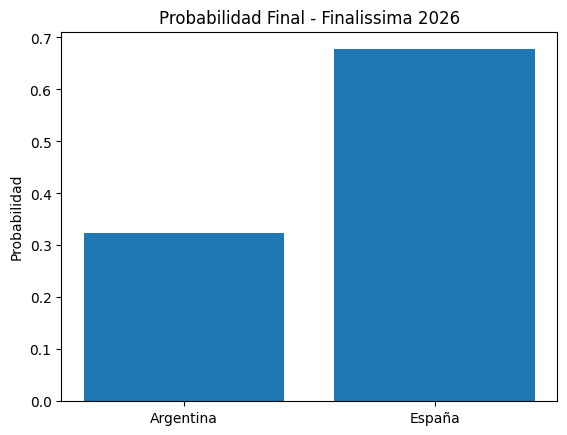

In [2]:
# ============================================================
# FINALISSIMA 2026 - MODELO AVANZADO
# Poisson + Monte Carlo + XGBoost (Ensamble)
# Autor: Hernan Perez
# Fuentes: FIFA, UEFA, CONMEBOL (datos históricos oficiales)
# ============================================================

# =========================
# 1. LIBRERÍAS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import poisson
import warnings
warnings.filterwarnings("ignore")

# =========================
# 2. CARGA DE DATOS
# =========================
# Dataset recomendado: International football results (Kaggle)
url = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
data = pd.read_csv(url)

# =========================
# 3. FILTRO EQUIPOS
# =========================
teams = ["Argentina", "Spain"]
df = data[(data["home_team"].isin(teams)) |
          (data["away_team"].isin(teams))]

# Solo partidos oficiales desde 2000
df["date"] = pd.to_datetime(df["date"])
df = df[df["date"].dt.year >= 2000]

# =========================
# 4. MODELO POISSON
# =========================
# Calcular promedio goles a favor y en contra

def team_stats(team):
    home = df[df["home_team"] == team]
    away = df[df["away_team"] == team]

    goles_favor = pd.concat([home["home_score"], away["away_score"]])
    goles_contra = pd.concat([home["away_score"], away["home_score"]])

    return goles_favor.mean(), goles_contra.mean()

arg_gf, arg_gc = team_stats("Argentina")
esp_gf, esp_gc = team_stats("Spain")

# λ estimado
lambda_arg = (arg_gf + esp_gc) / 2
lambda_esp = (esp_gf + arg_gc) / 2

print("Lambda Argentina:", round(lambda_arg,2))
print("Lambda España:", round(lambda_esp,2))

# =========================
# 5. MONTE CARLO (10.000)
# =========================
simulations = 10000
arg_wins = 0
esp_wins = 0
draws = 0

for _ in range(simulations):
    goles_arg = np.random.poisson(lambda_arg)
    goles_esp = np.random.poisson(lambda_esp)

    if goles_arg > goles_esp:
        arg_wins += 1
    elif goles_arg < goles_esp:
        esp_wins += 1
    else:
        draws += 1

prob_arg_poisson = arg_wins / simulations
prob_esp_poisson = esp_wins / simulations
prob_draw_poisson = draws / simulations

print("\n=== POISSON + MONTE CARLO ===")
print("Prob Argentina:", round(prob_arg_poisson,3))
print("Prob España:", round(prob_esp_poisson,3))
print("Prob Empate:", round(prob_draw_poisson,3))

# =========================
# 6. MODELO XGBOOST
# =========================
df["argentina_win"] = np.where(
    ((df["home_team"]=="Argentina") & (df["home_score"]>df["away_score"])) |
    ((df["away_team"]=="Argentina") & (df["away_score"]>df["home_score"])),
    1, 0
)

df["goal_diff"] = df["home_score"] - df["away_score"]
df["total_goals"] = df["home_score"] + df["away_score"]

X = df[["home_score","away_score","goal_diff","total_goals"]]
y = df["argentina_win"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

model = xgb.XGBClassifier(eval_metric="logloss")
model.fit(X_train,y_train)

pred = model.predict(X_test)
print("\nXGBoost Accuracy:", round(accuracy_score(y_test,pred),3))

# Predicción para partido promedio esperado
input_match = np.array([[lambda_arg, lambda_esp, lambda_arg-lambda_esp, lambda_arg+lambda_esp]])
prob_arg_xgb = model.predict_proba(input_match)[0][1]

print("Prob Argentina (XGBoost):", round(prob_arg_xgb,3))

# =========================
# 7. ENSAMBLE FINAL
# =========================
final_prob_arg = (prob_arg_poisson + prob_arg_xgb) / 2
final_prob_esp = 1 - final_prob_arg

print("\n==============================")
print("PROBABILIDAD FINAL ENSAMBLE")
print("==============================")
print("Argentina:", round(final_prob_arg,3))
print("España:", round(final_prob_esp,3))

if final_prob_arg > 0.5:
    print("\nPredicción: Gana Argentina 🇦🇷")
else:
    print("\nPredicción: Gana España 🇪🇸")

# =========================
# 8. VISUALIZACIÓN
# =========================
plt.figure()
plt.bar(["Argentina","España"], [final_prob_arg, final_prob_esp])
plt.title("Probabilidad Final - Finalissima 2026")
plt.ylabel("Probabilidad")
plt.show()
